# MODULE 1 — EDA & Data Cleaning
## explore.ipynb

This notebook performs comprehensive exploratory data analysis on `dataset_ProjetML_2026.csv`:
1. Load raw CSV — print shape, dtypes, `.describe()`, `.info()`
2. Visualizations — histograms, countplots, correlation heatmap, missing-value heatmap
3. Little's MCAR test approximation — classify each column as MCAR / MAR / MNAR
4. Outlier detection — IQR method AND Z-score (flag rows, do NOT drop)
5. Save `raw_stats.json` summary for reproducibility

---
## 0 · Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import json, os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Paths
RAW_CSV = os.path.join('..', '..', 'dataset_ProjetML_2026.csv')
OUTPUT_DIR = os.path.join('..', '..', 'data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## 1 · Load Raw Data & Basic Statistics

In [2]:
df = pd.read_csv(RAW_CSV)
print('=== Shape ===')
print(df.shape)
print()
print('=== Dtypes ===')
print(df.dtypes)
print()
print('=== Info ===')
df.info()
print()
print('=== Describe (numeric) ===')
df.describe()

=== Shape ===
(10500, 9)

=== Dtypes ===
Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie               str
Source                  str
Rapport_Collecte        str
dtype: object

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   str    
 7   Source            9964 non-null   str    
 8   Rapport_Collecte  10500 non-null  str    
dtypes: float64(6), str(3)
memory usage: 738.4 KB

=== Describe (

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [3]:
print('=== Describe (categorical) ===')
df.describe(include='object')

=== Describe (categorical) ===


,Categorie,Source,Rapport_Collecte
count,9986,9964,10500
unique,4,4,9336
top,Plastique,Collecte_Citoyenne,Ferraille ou métal collecté via la collecte ci...
freq,2795,2644,8


In [4]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [5]:
print('=== Missing values per column ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'count': missing, 'pct': missing_pct})

=== Missing values per column ===


,count,pct
Poids,1029,9.80
Volume,540,5.14
Conductivite,1017,9.69
Opacite,1035,9.86
Rigidite,558,5.31
Prix_Revente,536,5.10
Categorie,514,4.90
Source,536,5.10
Rapport_Collecte,0,0.00


---
## 2 · Visualizations

### 2.1 Histograms for each numeric feature

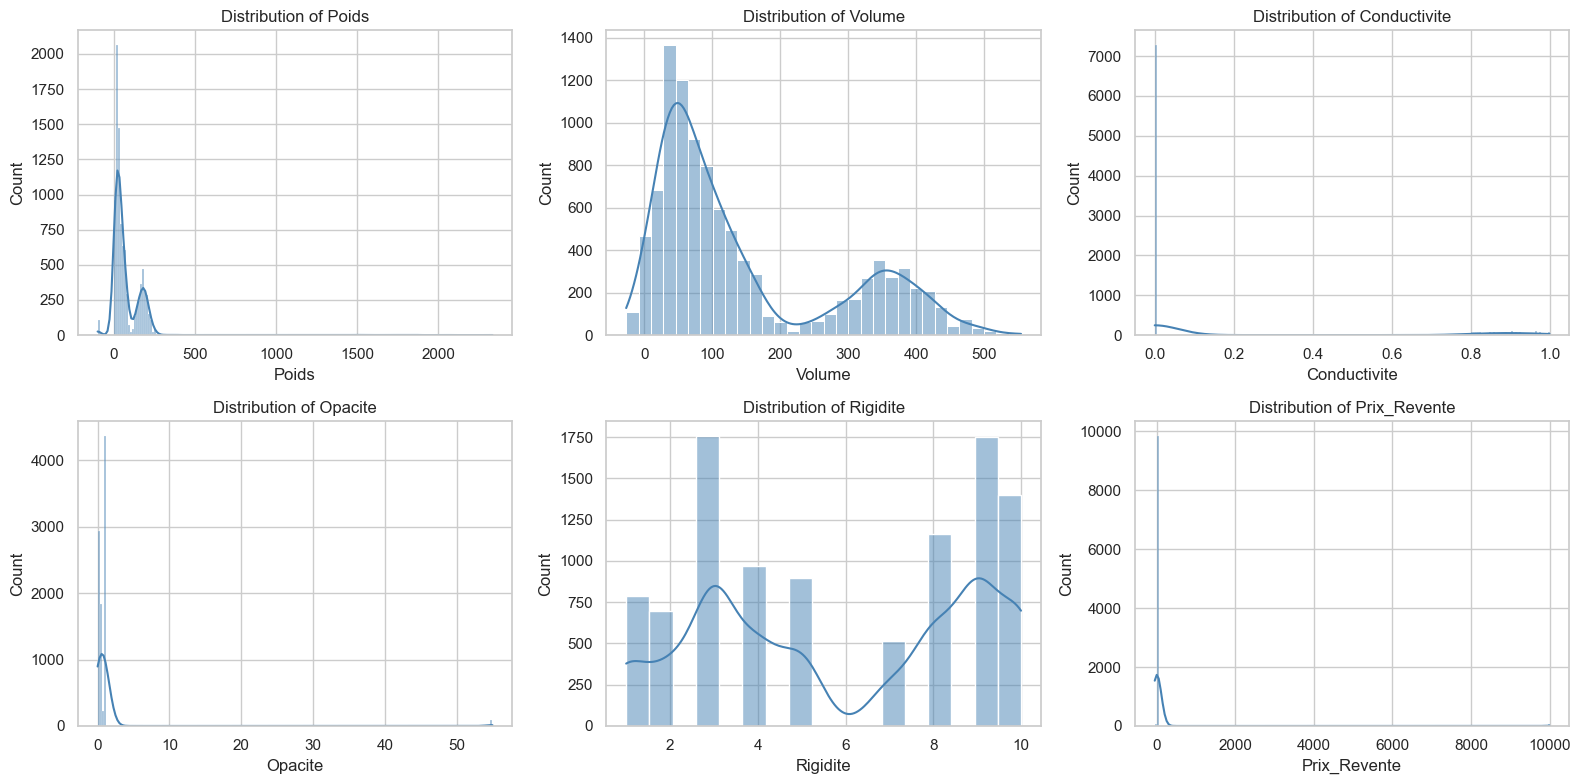

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(16, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 2.2 Countplots for Source and Categorie

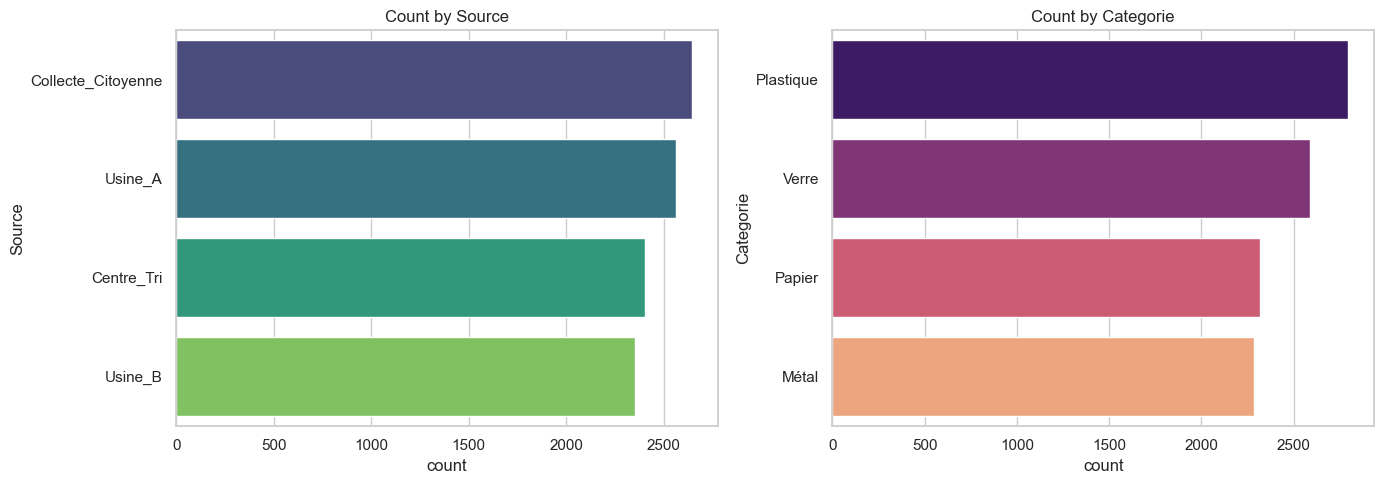

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, y='Source', order=df['Source'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Count by Source')
sns.countplot(data=df, y='Categorie', order=df['Categorie'].value_counts().index, ax=axes[1], palette='magma')
axes[1].set_title('Count by Categorie')
plt.tight_layout()
plt.show()

### 2.3 Correlation heatmap

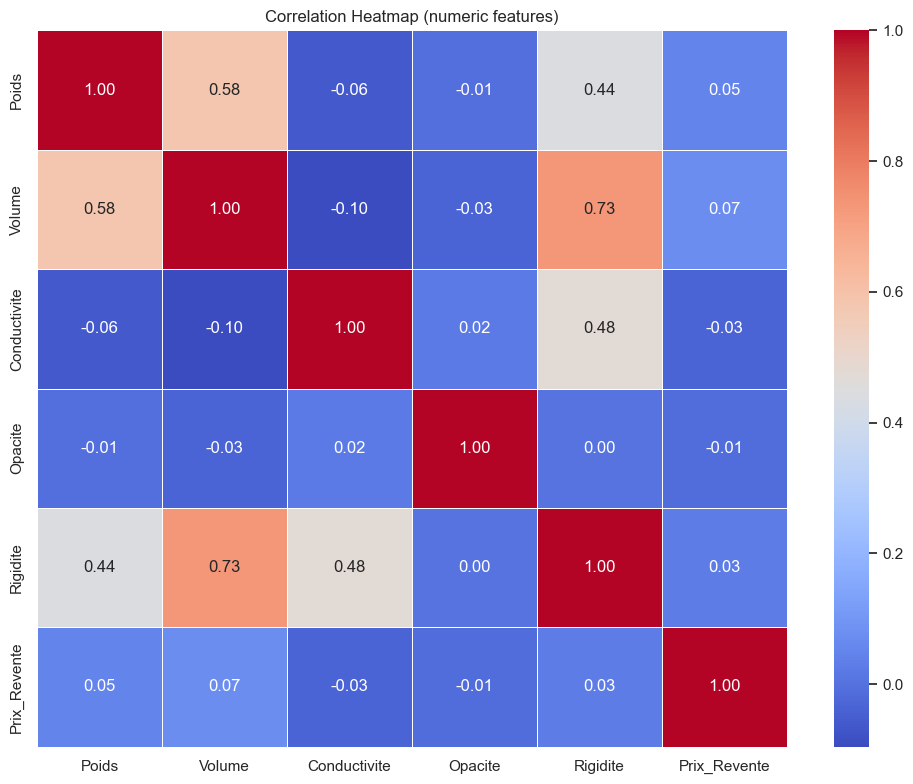

In [8]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

### 2.4 Missing-value heatmap (missingno)

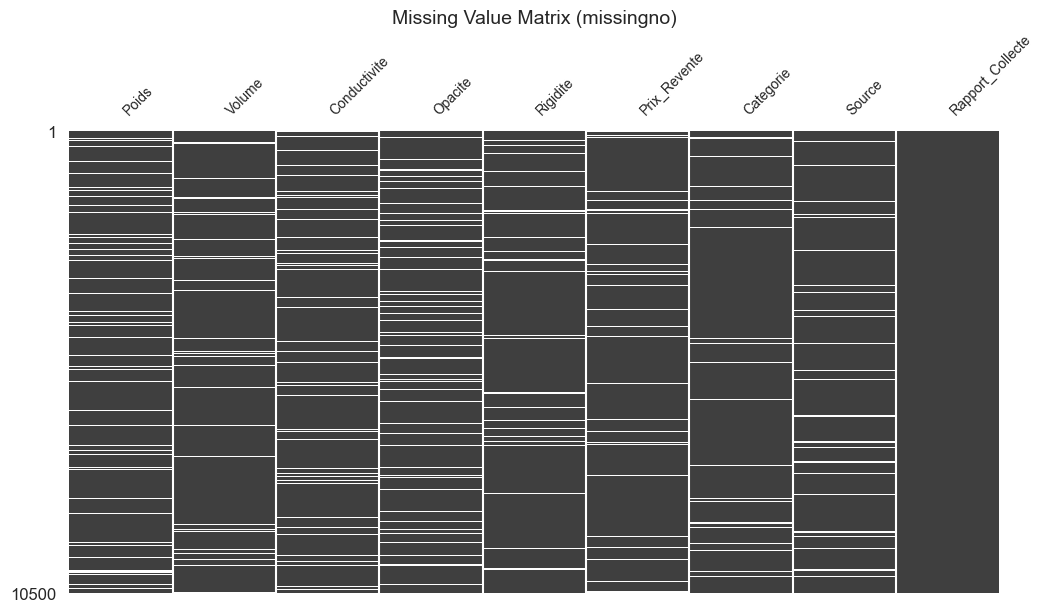

In [9]:
msno.matrix(df, figsize=(12, 6), fontsize=10, sparkline=False)
plt.title('Missing Value Matrix (missingno)', fontsize=14)
plt.show()

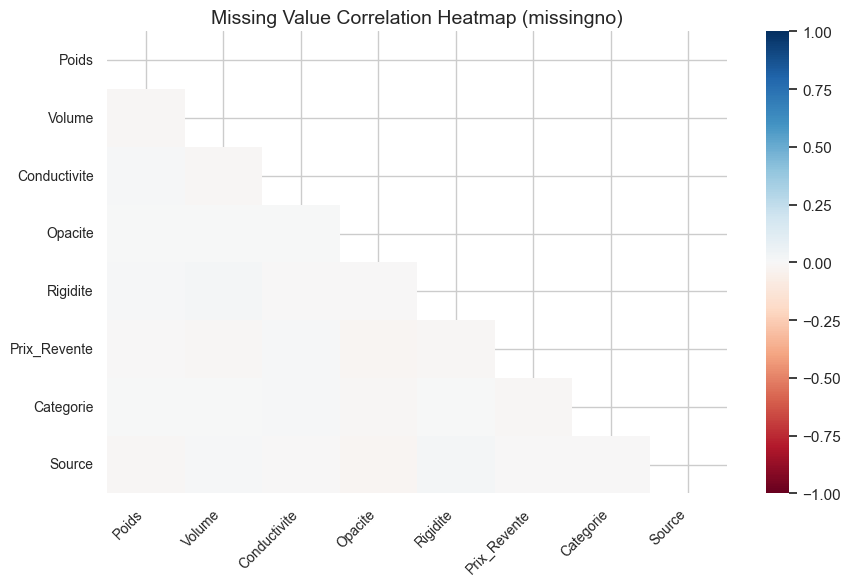

In [10]:
msno.heatmap(df, figsize=(10, 6), fontsize=10)
plt.title('Missing Value Correlation Heatmap (missingno)', fontsize=14)
plt.show()

---
## 3 · Little's MCAR Test Approximation

**Background:**
- **MCAR (Missing Completely At Random):** Missingness is independent of both observed and unobserved data.
- **MAR (Missing At Random):** Missingness depends on observed data but NOT on the missing values themselves.
- **MNAR (Missing Not At Random):** Missingness depends on the missing values themselves.

**Approach (approximation):**

Little's full MCAR test uses a chi-squared statistic on mean differences across missing-data patterns.
Here we approximate by:
1. For each column with missing values, split the dataset into two groups based on whether the value is missing.
2. Compare the distributions of other numeric columns between the two groups using t-tests.
3. If NO other column's distribution differs significantly → likely **MCAR**.
4. If OTHER OBSERVED columns differ significantly → likely **MAR**.
5. If domain knowledge suggests the value is missing BECAUSE of the value itself → **MNAR** (requires manual inspection — e.g., sensor can't read extreme values).

In [11]:
ALPHA = 0.05
cols_with_missing = [c for c in df.columns if df[c].isnull().any()]

mcar_results = {}

for col in cols_with_missing:
    is_missing = df[col].isnull()
    significant_cols = []

    for other in numeric_cols:
        if other == col:
            continue
        grp_present = df.loc[~is_missing, other].dropna()
        grp_missing = df.loc[is_missing, other].dropna()
        if len(grp_present) < 2 or len(grp_missing) < 2:
            continue
        t_stat, p_val = stats.ttest_ind(grp_present, grp_missing, equal_var=False)
        if p_val < ALPHA:
            significant_cols.append((other, round(p_val, 6)))

    if len(significant_cols) == 0:
        classification = 'MCAR'
        comment = (f"No significant mean differences found in other numeric columns "
                   f"when '{col}' is missing vs. present → missingness appears "
                   f"independent of observed data (MCAR).")
    else:
        classification = 'MAR'
        sig_names = [s[0] for s in significant_cols]
        comment = (f"Significant mean differences detected in {sig_names} "
                   f"when '{col}' is missing vs. present → missingness likely "
                   f"depends on observed data (MAR). "
                   f"Note: could be MNAR if the value is missing BECAUSE of "
                   f"its own magnitude (e.g., sensor saturation). "
                   f"Domain inspection recommended.")

    mcar_results[col] = {
        'n_missing': int(is_missing.sum()),
        'pct_missing': round(is_missing.mean() * 100, 2),
        'classification': classification,
        'significant_cols': significant_cols,
        'comment': comment
    }

for col, info in mcar_results.items():
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"  Missing: {info['n_missing']} ({info['pct_missing']}%)")
    print(f"  Classification: {info['classification']}")
    print(f"  Comment: {info['comment']}")


Column: Poids
  Missing: 1029 (9.8%)
  Classification: MAR
  Comment: Significant mean differences detected in ['Volume', 'Conductivite', 'Prix_Revente'] when 'Poids' is missing vs. present → missingness likely depends on observed data (MAR). Note: could be MNAR if the value is missing BECAUSE of its own magnitude (e.g., sensor saturation). Domain inspection recommended.

Column: Volume
  Missing: 540 (5.14%)
  Classification: MCAR
  Comment: No significant mean differences found in other numeric columns when 'Volume' is missing vs. present → missingness appears independent of observed data (MCAR).

Column: Conductivite
  Missing: 1017 (9.69%)
  Classification: MAR
  Comment: Significant mean differences detected in ['Prix_Revente'] when 'Conductivite' is missing vs. present → missingness likely depends on observed data (MAR). Note: could be MNAR if the value is missing BECAUSE of its own magnitude (e.g., sensor saturation). Domain inspection recommended.

Column: Opacite
  Missing: 1

---
## 4 · Outlier Detection (IQR & Z-score)

We flag rows but **do NOT drop them** at this stage.

### 4.1 IQR Method

In [12]:
iqr_outlier_flags = pd.DataFrame(index=df.index)
iqr_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    flag = ((df[col] < lower) | (df[col] > upper))
    iqr_outlier_flags[f'{col}_iqr_outlier'] = flag
    n_out = flag.sum()
    iqr_summary[col] = {
        'Q1': round(Q1, 4), 'Q3': round(Q3, 4), 'IQR': round(IQR, 4),
        'lower_bound': round(lower, 4), 'upper_bound': round(upper, 4),
        'n_outliers': int(n_out), 'pct_outliers': round(n_out / len(df) * 100, 2)
    }
    print(f"{col}: {n_out} outliers ({iqr_summary[col]['pct_outliers']}%) "
          f"[{lower:.2f}, {upper:.2f}]")

Poids: 61 outliers (0.58%) [-146.37, 296.62]
Volume: 12 outliers (0.11%) [-249.21, 533.84]
Conductivite: 2200 outliers (20.95%) [0.00, 0.00]
Opacite: 97 outliers (0.92%) [-1.01, 2.21]
Rigidite: 0 outliers (0.0%) [-6.00, 18.00]
Prix_Revente: 1734 outliers (16.51%) [-6.69, 14.86]


### 4.2 Z-score Method (|z| > 3)

In [13]:
Z_THRESHOLD = 3
zscore_outlier_flags = pd.DataFrame(index=df.index)
zscore_summary = {}

for col in numeric_cols:
    col_data = df[col].dropna()
    z = np.abs(stats.zscore(col_data))
    outlier_idx = col_data.index[z > Z_THRESHOLD]
    flag = pd.Series(False, index=df.index)
    flag.loc[outlier_idx] = True
    zscore_outlier_flags[f'{col}_zscore_outlier'] = flag
    n_out = int(flag.sum())
    zscore_summary[col] = {
        'z_threshold': Z_THRESHOLD,
        'n_outliers': n_out,
        'pct_outliers': round(n_out / len(df) * 100, 2)
    }
    print(f"{col}: {n_out} outliers ({zscore_summary[col]['pct_outliers']}%) "
          f"[|z| > {Z_THRESHOLD}]")

Poids: 48 outliers (0.46%) [|z| > 3]
Volume: 12 outliers (0.11%) [|z| > 3]
Conductivite: 0 outliers (0.0%) [|z| > 3]
Opacite: 97 outliers (0.92%) [|z| > 3]
Rigidite: 0 outliers (0.0%) [|z| > 3]
Prix_Revente: 52 outliers (0.5%) [|z| > 3]


### 4.3 Combined outlier flag

In [14]:
df['is_outlier_iqr'] = iqr_outlier_flags.any(axis=1)
df['is_outlier_zscore'] = zscore_outlier_flags.any(axis=1)
df['is_outlier_any'] = df['is_outlier_iqr'] | df['is_outlier_zscore']

print(f"Rows flagged by IQR:     {df['is_outlier_iqr'].sum()}")
print(f"Rows flagged by Z-score: {df['is_outlier_zscore'].sum()}")
print(f"Rows flagged by either:  {df['is_outlier_any'].sum()}")
print(f"Total rows:              {len(df)}")

Rows flagged by IQR:     2560
Rows flagged by Z-score: 207
Rows flagged by either:  2560
Total rows:              10500


### 4.4 Boxplots for visual inspection

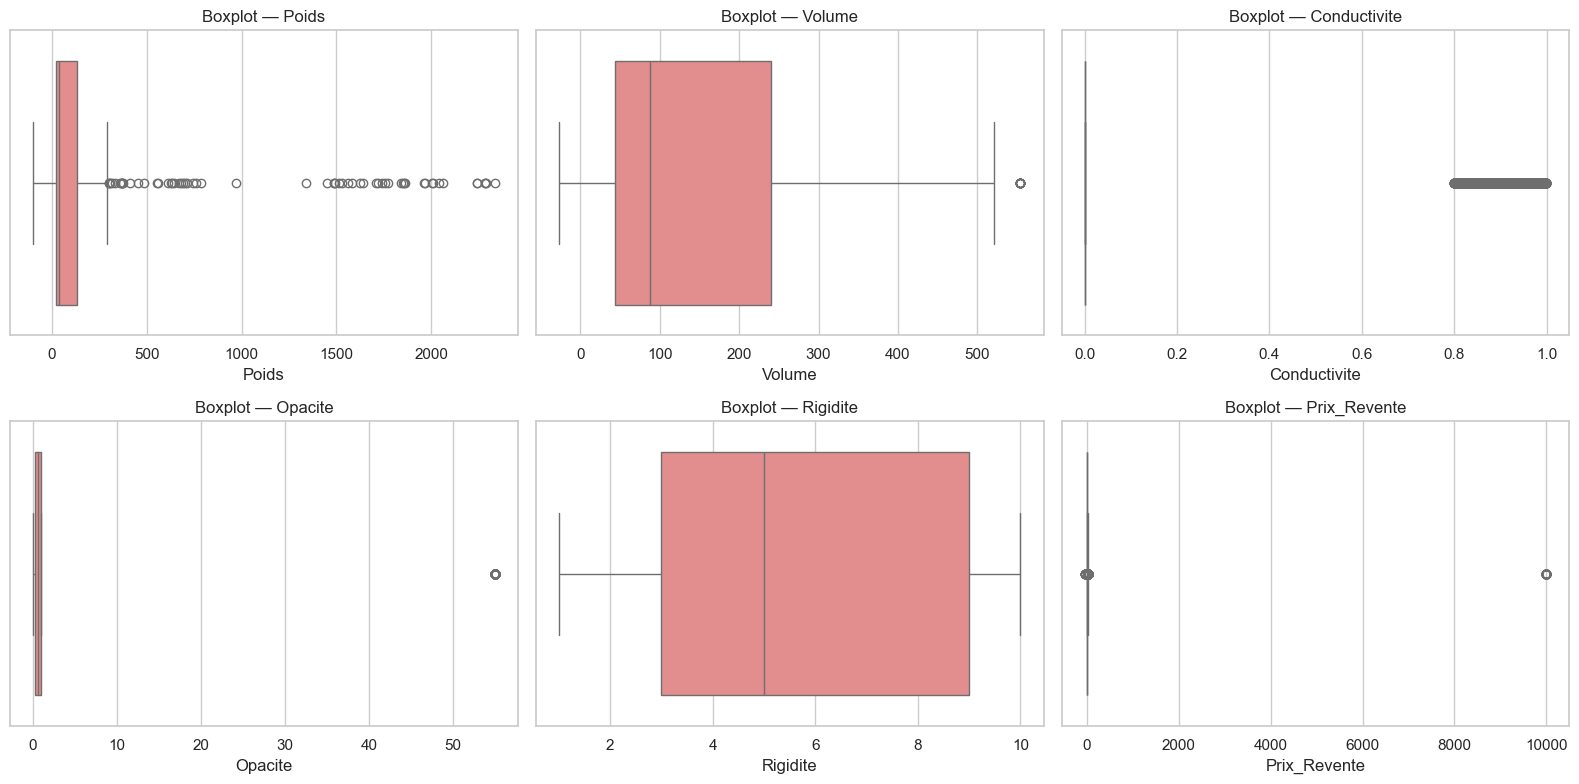

In [15]:
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(16, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot — {col}')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5 · Save `raw_stats.json`

In [16]:
raw_stats = {
    'shape': {'rows': int(df.shape[0]), 'cols': int(df.shape[1])},
    'dtypes': {col: str(dtype) for col, dtype in df.dtypes.items()},
    'describe_numeric': df[numeric_cols].describe().to_dict(),
    'missing_values': {
        col: {'count': int(df[col].isnull().sum()),
              'pct': round(df[col].isnull().mean() * 100, 2)}
        for col in df.columns
    },
    'mcar_analysis': mcar_results,
    'outlier_detection': {
        'iqr_method': iqr_summary,
        'zscore_method': zscore_summary,
        'total_flagged_iqr': int(df['is_outlier_iqr'].sum()),
        'total_flagged_zscore': int(df['is_outlier_zscore'].sum()),
        'total_flagged_any': int(df['is_outlier_any'].sum())
    }
}

output_path = os.path.join(OUTPUT_DIR, 'raw_stats.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(raw_stats, f, indent=2, ensure_ascii=False, default=str)

print(f'raw_stats.json saved to {os.path.abspath(output_path)}')

raw_stats.json saved to c:\Users\User\Desktop\Proj WHO\data\raw_stats.json


In [17]:
print('\n=== EDA & Data Cleaning Module 1 — Complete ===')
print(f'Dataset: {RAW_CSV}')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print(f'Outlier-flagged rows (any method): {df["is_outlier_any"].sum()}')
print(f'Stats saved to: {os.path.abspath(output_path)}')


=== EDA & Data Cleaning Module 1 — Complete ===
Dataset: ..\..\dataset_ProjetML_2026.csv
Rows: 10500  |  Columns: 12
Outlier-flagged rows (any method): 2560
Stats saved to: c:\Users\User\Desktop\Proj WHO\data\raw_stats.json
